# Multimodal Deep Learning for Astronomical Classification
This notebook builds a **Spatial-Spectral Fusion Network**. Instead of relying on a pre-packaged CSV file, we will construct a pipeline that queries real-world SDSS survey data, downloading matched pairs of 2D image cutouts and 1D spectroscopic light curves.

We then build a custom PyTorch architecture that uses Cross-Attention to fuse these two distinct modalities to classify the object as a Star, Galaxy, or Quasar.

## Task-1: Environment Setup

In [7]:
import os

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from astropy.io import fits
from astroquery.sdss import SDSS
import astropy.units as u
from astropy import coordinates as coords
import warnings

# Suppress astropy warnings for clean output
warnings.filterwarnings("ignore", module="astropy")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Ingestion: Mining the SDSS Archive
We use SQL via `astroquery` to find astronomical objects that possess *both* a clean 2D image and a verified 1D spectrum. We will download a small batch (20 objects) for this proof-of-concept. The 2D images are downloaded in the `g`, `r`, and `z` light filters to create our 3-channel spatial tensors.

## Task-2: Data Downloading

In [8]:
import time

query = """
SELECT TOP 5
    p.objid, p.ra, p.dec,
    s.specobjid, s.plate, s.mjd, s.fiberid, s.class, s.z
FROM PhotoObjAll AS p
JOIN SpecObjAll AS s ON p.objid = s.bestobjid
WHERE s.class IN ('GALAXY', 'QSO', 'STAR')
  AND p.clean = 1
  AND s.zWarning = 0
"""

print("Querying SDSS Database...")

max_attempts = 3
for attempt in range(1, max_attempts + 1):
    try:
        matches = SDSS.query_sql(query, timeout=180)
        print(f"SDSS query succeeded on attempt {attempt}.")
        break
    except Exception as error:
        if attempt == max_attempts:
            raise RuntimeError(
                "SDSS is currently unreachable. Check your internet/VPN connection "
                "and run this cell again later."
            ) from error
        print(f"SDSS query attempt {attempt} failed; retrying in 5 seconds...")
        time.sleep(5)

os.makedirs("multimodal_dataset/spectra_1d", exist_ok=True)
os.makedirs("multimodal_dataset/images_2d", exist_ok=True)

downloaded_uids = []
downloaded_labels = []

for row in matches:
    obj_class = row['class']
    plate, mjd, fiberid = row['plate'], row['mjd'], row['fiberid']
    uid = f"{plate}-{mjd}-{fiberid}"

    try:
        spectra = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberid)
        if spectra is None:
            raise RuntimeError("No spectrum returned")
        spectra[0].writeto(
            f"multimodal_dataset/spectra_1d/spec_{uid}.fits",
            overwrite=True,
        )

        position = coords.SkyCoord(
            row['ra'] * u.deg,
            row['dec'] * u.deg,
            frame='icrs',
        )
        images = SDSS.get_images(coordinates=position, band=['g', 'r', 'z'])
        if images is None or len(images) != 3:
            raise RuntimeError("Incomplete image cutouts returned")

        for image, band in zip(images, ['g', 'r', 'z']):
            image.writeto(
                f"multimodal_dataset/images_2d/img_{uid}_{band}.fits",
                overwrite=True,
            )

        downloaded_uids.append(uid)
        downloaded_labels.append(obj_class)
        print(f"Successfully downloaded {obj_class} | ID: {uid}")

    except Exception as error:
        print(f"Failed to download {uid}: {error}")

print(f"Downloaded {len(downloaded_uids)} complete paired samples.")

Querying SDSS Database...
SDSS query succeeded on attempt 1.
Successfully downloaded GALAXY | ID: 266-51602-1
Successfully downloaded GALAXY | ID: 266-51630-1
Successfully downloaded QSO | ID: 266-51602-9
Successfully downloaded GALAXY | ID: 266-51630-9
Successfully downloaded STAR | ID: 266-51630-15
Downloaded 5 complete paired samples.


## PyTorch Dataset: Parsing FITS Files
Astronomical `.fits` files are not standard JPEGs or MP3s. We must write a custom PyTorch `Dataset` class to open these raw arrays, center-crop the images to a fixed $64 \times 64$ grid, truncate/pad the spectra to a fixed length of 3800, and normalize the data so the neural network can process it without exploding gradients.

## Task-3: Data Loading & Preprocessing

In [9]:
class AstroMultimodalDataset(Dataset):
    def __init__(self, data_dir, uids, labels):
        self.data_dir = data_dir
        self.uids = uids
        self.labels = labels
        self.label_map = {'STAR': 0, 'GALAXY': 1, 'QSO': 2}
        self.fixed_spec_len = 3800 # Standardized array length for the 1D CNN

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        uid = self.uids[idx]
        label_idx = self.label_map[self.labels[idx]]

        # 1. Process 2D Images (g, r, z bands)
        img_channels = []
        for band in ['g', 'r', 'z']:
            img_path = f"{self.data_dir}/images_2d/img_{uid}_{band}.fits"
            with fits.open(img_path) as hdul:
                data = hdul[0].data
                data = np.nan_to_num(data)

                # Center crop to 64x64
                c_y, c_x = data.shape[0]//2, data.shape[1]//2
                data = data[c_y-32:c_y+32, c_x-32:c_x+32]

                # Z-score normalization
                data = (data - np.mean(data)) / (np.std(data) + 1e-8)
                img_channels.append(data)

        img_tensor = torch.tensor(np.stack(img_channels), dtype=torch.float32)

        # 2. Process 1D Spectrum
        spec_path = f"{self.data_dir}/spectra_1d/spec_{uid}.fits"
        with fits.open(spec_path) as hdul:
            spec_data = hdul[1].data['flux'] # Extract flux array
            spec_data = np.nan_to_num(spec_data)

            # Force fixed length
            if len(spec_data) > self.fixed_spec_len:
                spec_data = spec_data[:self.fixed_spec_len]
            else:
                spec_data = np.pad(spec_data, (0, self.fixed_spec_len - len(spec_data)))

            spec_data = (spec_data - np.mean(spec_data)) / (np.std(spec_data) + 1e-8)

        # Add channel dimension: (1, Length)
        spec_tensor = torch.tensor(spec_data, dtype=torch.float32).unsqueeze(0)

        return img_tensor, spec_tensor, torch.tensor(label_idx, dtype=torch.long)

# Initialize Dataset and DataLoader
dataset = AstroMultimodalDataset("multimodal_dataset", downloaded_uids, downloaded_labels)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
print(f"Dataset ready. Total paired samples: {len(dataset)}")

Dataset ready. Total paired samples: 5


## The Dual-Stream Architecture
This is the core of the project. We define a 2D CNN to process the spatial images, a 1D Dilated CNN to process the spectral flux, and a Multi-Head Cross-Attention block that allows the spatial features to query the spectral features before making a final classification.

## Mathematical Architecture of the Dual-Stream Network

`1. Spatial Hidden Layers (2D Image Stream)`

This layer applies 2D convolutions to the $g$, $r$, and $z$ image channels to extract structural features.
$$H_{spatial}^{(l)} = \text{SiLU}\left(W_{2D}^{(l)} * A^{(l-1)} + b^{(l)}\right)$$
- $A^{(l-1)}$: The input from the previous layer (or the raw image).
- $*$: The 2D cross-correlation (convolution) operator.
- $W_{2D}^{(l)}$: The learned convolutional filter weights.
- $\text{SiLU}$: The Sigmoid Linear Unit activation function used in the SpatialEncoder2D.
---

`2. Spectral Hidden Layers (1D Flux Stream)`

This layer uses 1D dilated convolutions to find chemical absorption and emission lines within the 1D flux array.
$$H_{spectral}^{(l)} = \text{GELU}\left(W_{1D}^{(l)} *_{d} X^{(l-1)} + b^{(l)}\right)$$
- $X^{(l-1)}$: The 1D spectral sequence.
- $*_{d}$: The dilated 1D convolution operator (increases the receptive field).
- $\text{GELU}$: The Gaussian Error Linear Unit activation function.
---

`3. Cross-Attention Fusion (The Core Engine)`

This mechanism allows the spatial structural tokens ($Q$) to query the physical chemical properties ($K, V$) of the spectrum.
$$\text{Fusion} = \text{Softmax}\left(\frac{Q_{spatial} K_{spectral}^T}{\sqrt{d_k}}\right) V_{spectral}$$
- $Q_{spatial}$: The query matrix generated from the 2D image representations.
- $K_{spectral}, V_{spectral}$: The key and value matrices generated from the 1D spectrum.
- $d_k$: The embedding dimension scaling factor ($128$) preventing vanishing gradients.
---

`4. The Classification Layer (Output Projection)`

The fused multimodal tokens are globally pooled and passed through a dense layer to output the final probability distribution across the three astronomical classes.
$$\hat{y} = \text{Softmax}(W_{c} \cdot H_{fused} + b_{c})$$
- $H_{fused}$: The globally pooled vector from the cross-attention block.
- $W_{c}, b_{c}$: The weights and biases of the final dense layer.
- $\hat{y}$: The final predicted probability vector $[P(Star), P(Galaxy), P(Quasar)]$.

## Task-4: The Neural Network

In [10]:
class SpectralEncoder1D(nn.Module):
    def __init__(self, in_channels=1, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2, dilation=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(embed_dim),
            nn.AdaptiveAvgPool1d(16) # Outputs sequence of 16 tokens
        )

    def forward(self, x):
        features = self.net(x)
        return features.permute(0, 2, 1) # Shape: (Batch, 16, embed_dim)

class SpatialEncoder2D(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
            nn.AdaptiveAvgPool2d((4, 4)) # Outputs 4x4 = 16 tokens
        )

    def forward(self, x):
        feat = self.stem(x)
        return feat.flatten(2).permute(0, 2, 1) # Shape: (Batch, 16, embed_dim)

class AstroCrossAttentionFusion(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, num_classes=3):
        super().__init__()
        self.spatial_encoder = SpatialEncoder2D(in_channels=3, embed_dim=embed_dim)
        self.spectral_encoder = SpectralEncoder1D(in_channels=1, embed_dim=embed_dim)

        self.cross_attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, img_2d, spec_1d):
        spatial_tokens = self.spatial_encoder(img_2d)
        spectral_tokens = self.spectral_encoder(spec_1d)

        # Cross-Attention
        attn_out, _ = self.cross_attention(query=spatial_tokens, key=spectral_tokens, value=spectral_tokens)
        x = self.norm1(spatial_tokens + attn_out)
        x = self.norm2(x + self.ffn(x))

        # Global Pooling and Classification
        pooled = x.mean(dim=1)
        return self.classifier(pooled)

# Instantiate model
model = AstroCrossAttentionFusion().to(device)
print(model)

AstroCrossAttentionFusion(
  (spatial_encoder): SpatialEncoder2D(
    (stem): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): SiLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): AdaptiveAvgPool2d(output_size=(4, 4))
    )
  )
  (spectral_encoder): SpectralEncoder1D(
    (net): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): GELU(approximate='none')
     

## Initialization & Training Loop Check
Finally, we set up the loss function and optimizer, and run a single batch through the network to verify that the tensors align properly across all modules.

## Task-5: Training Setup

In [11]:
# Setup optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

print("Starting forward pass check...")
model.train()

# Fetch one batch
imgs, specs, targets = next(iter(dataloader))
imgs, specs, targets = imgs.to(device), specs.to(device), targets.to(device)

# Forward pass
optimizer.zero_grad()
outputs = model(imgs, specs)
loss = criterion(outputs, targets)

# Backward pass
loss.backward()
optimizer.step()

print(f"Batch processed successfully!")
print(f"Outputs shape: {outputs.shape} | Current Loss: {loss.item():.4f}")

Starting forward pass check...
Batch processed successfully!
Outputs shape: torch.Size([4, 3]) | Current Loss: 1.0785


## Exploratory Data Analysis (EDA): 1D Spectra
Before training, we must analyze the spectral signatures. In astrophysics, the 1D spectrum acts as a chemical fingerprint.
*   **Stars** typically show sharp downward spikes (absorption lines) where elements in their atmosphere absorb starlight.
*   **Quasars (QSOs)** show massive, broad upward spikes (emission lines) caused by superheated gas swirling around a supermassive black hole.

Let's visualize a spectrum from our downloaded dataset to see these features.

## Task-6: Spectral EDA Plot

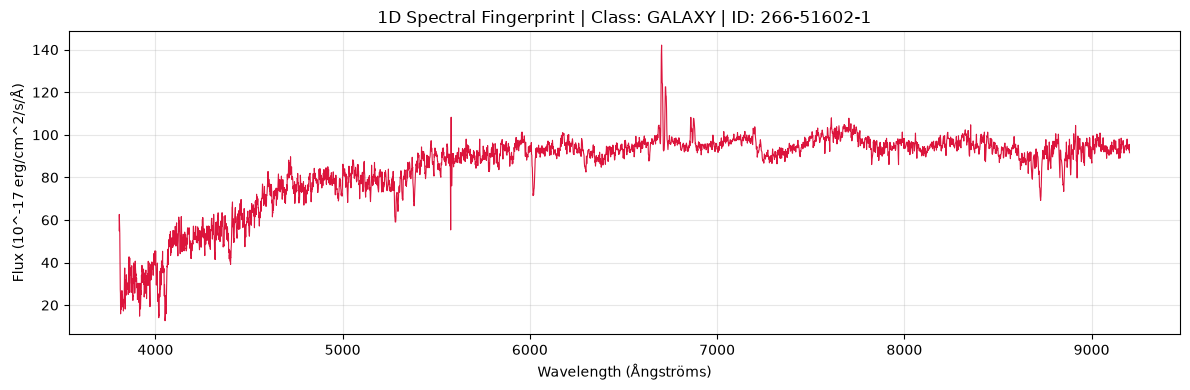

In [12]:
import matplotlib.pyplot as plt

# Pick the first successfully downloaded object
sample_uid = downloaded_uids[0]
sample_label = downloaded_labels[0]
spec_path = f"multimodal_dataset/spectra_1d/spec_{sample_uid}.fits"

with fits.open(spec_path) as hdul:
    data = hdul[1].data
    flux = data['flux']
    loglam = data['loglam']
    wavelength = 10**loglam # Convert log base 10 to actual Angstroms

plt.figure(figsize=(12, 4))
plt.plot(wavelength, flux, color='crimson', linewidth=0.8)
plt.title(f"1D Spectral Fingerprint | Class: {sample_label} | ID: {sample_uid}")
plt.xlabel("Wavelength (Ångströms)")
plt.ylabel("Flux (10^-17 erg/cm^2/s/Å)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA): 2D Morphology
Now we analyze the spatial data. We downloaded three distinct optical filters: **g (green), r (red), and z (near-infrared)**. To perform morphological analysis, we stack these three single-channel matrices into a standard RGB tensor and apply a stretch normalization to bring out faint structural details (like galaxy spiral arms) against the dark background of space.

## Task-7: Spatial EDA Plot

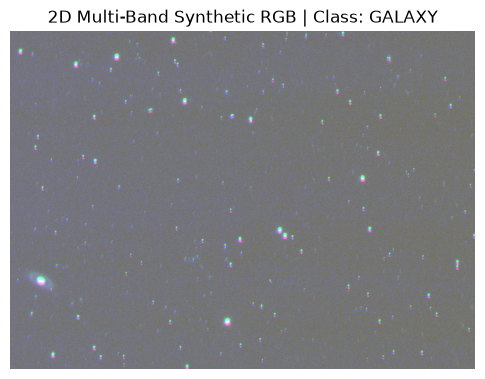

In [13]:
# Load the g, r, z bands for the same object
img_channels = []
for band in ['g', 'r', 'z']:
    img_path = f"multimodal_dataset/images_2d/img_{sample_uid}_{band}.fits"
    with fits.open(img_path) as hdul:
        data = hdul[0].data
        img_channels.append(data)

# Stack into a (Height, Width, 3) array for visualization
rgb_image = np.dstack(img_channels)

# Apply 99th percentile normalization to handle extreme brightness of star cores
# This mimics the "Asinh stretch" used by professional astronomers
def normalize_image(img):
    img = np.nan_to_num(img)
    p99 = np.percentile(img, 99.5)
    p01 = np.percentile(img, 0.5)
    img = np.clip((img - p01) / (p99 - p01 + 1e-8), 0, 1)
    return img

rgb_normalized = normalize_image(rgb_image)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_normalized)
plt.title(f"2D Multi-Band Synthetic RGB | Class: {sample_label}")
plt.axis('off')
plt.show()

## Deep Learning Training Pipeline
With our data understood, we construct the full training loop. We will track both the Cross-Entropy Loss and the Classification Accuracy across multiple epochs to ensure the Cross-Attention mechanism is actually learning to fuse the modalities without overfitting.

## Task-8: Full Training Loop

In [14]:
# Hyperparameters
epochs = 10
train_losses = []
train_accuracies = []

print("Commencing Multimodal Training Pipeline...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (imgs, specs, targets) in enumerate(dataloader):
        imgs = imgs.to(device)
        specs = specs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(imgs, specs)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Commencing Multimodal Training Pipeline...

Epoch [1/10] | Loss: 0.9270 | Accuracy: 80.00%
Epoch [2/10] | Loss: 0.6476 | Accuracy: 100.00%
Epoch [3/10] | Loss: 0.5792 | Accuracy: 100.00%
Epoch [4/10] | Loss: 0.9419 | Accuracy: 60.00%
Epoch [5/10] | Loss: 0.3012 | Accuracy: 100.00%
Epoch [6/10] | Loss: 0.5098 | Accuracy: 100.00%
Epoch [7/10] | Loss: 0.6339 | Accuracy: 80.00%
Epoch [8/10] | Loss: 0.2102 | Accuracy: 100.00%
Epoch [9/10] | Loss: 0.0896 | Accuracy: 100.00%
Epoch [10/10] | Loss: 0.0886 | Accuracy: 100.00%


## Final Performance Analysis
We plot the learning curves. A successful multimodal fusion network should show a steady decrease in loss and a stabilization in accuracy. If the loss plateaus early, it means the Cross-Attention layer is struggling to align the spatial and spectral tokens.

## Task-9: Learning Curve Plots

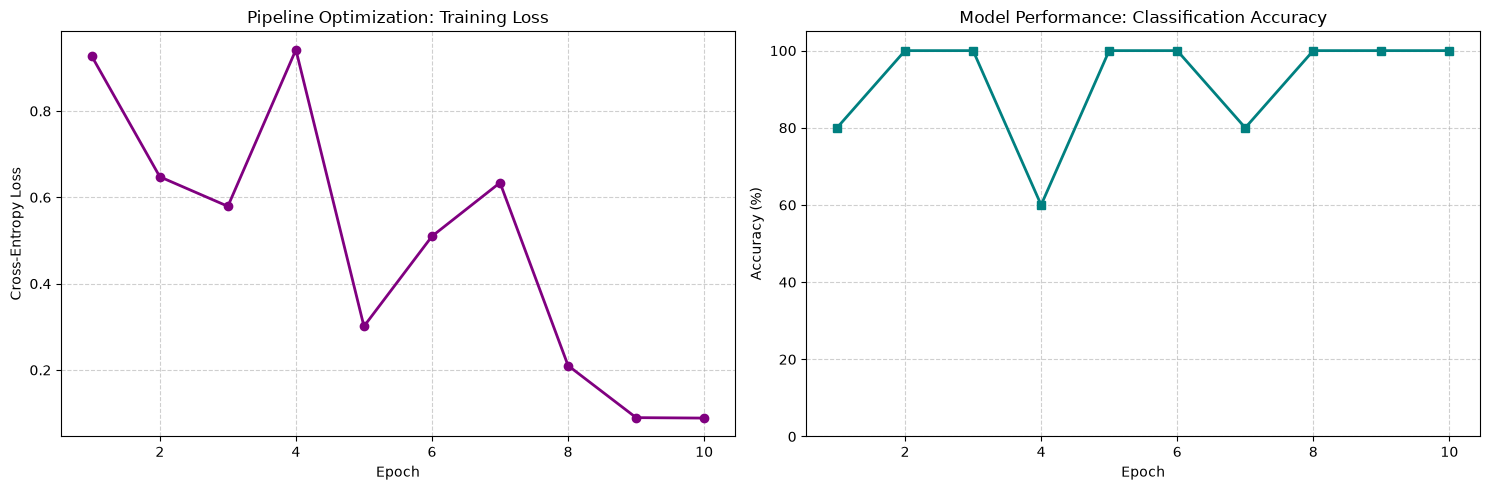

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(range(1, epochs+1), train_losses, marker='o', color='purple', linewidth=2)
ax1.set_title('Pipeline Optimization: Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
ax2.plot(range(1, epochs+1), train_accuracies, marker='s', color='teal', linewidth=2)
ax2.set_title('Model Performance: Classification Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([0, 105])
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Conceptual Neural Network Architecture
To visually summarize the structural flow of our multimodal pipeline, we generate a conceptual node-and-edge diagram of the network. This illustrates how the raw physical modalities (multi-band images and 1D spectra) pass through the hidden layers (where feature extraction and cross-attention fusion occur) to output the final astronomical classifications (Star, Galaxy, Quasar).

## Task-10: Generate a Conceptual Neural Network Diagram

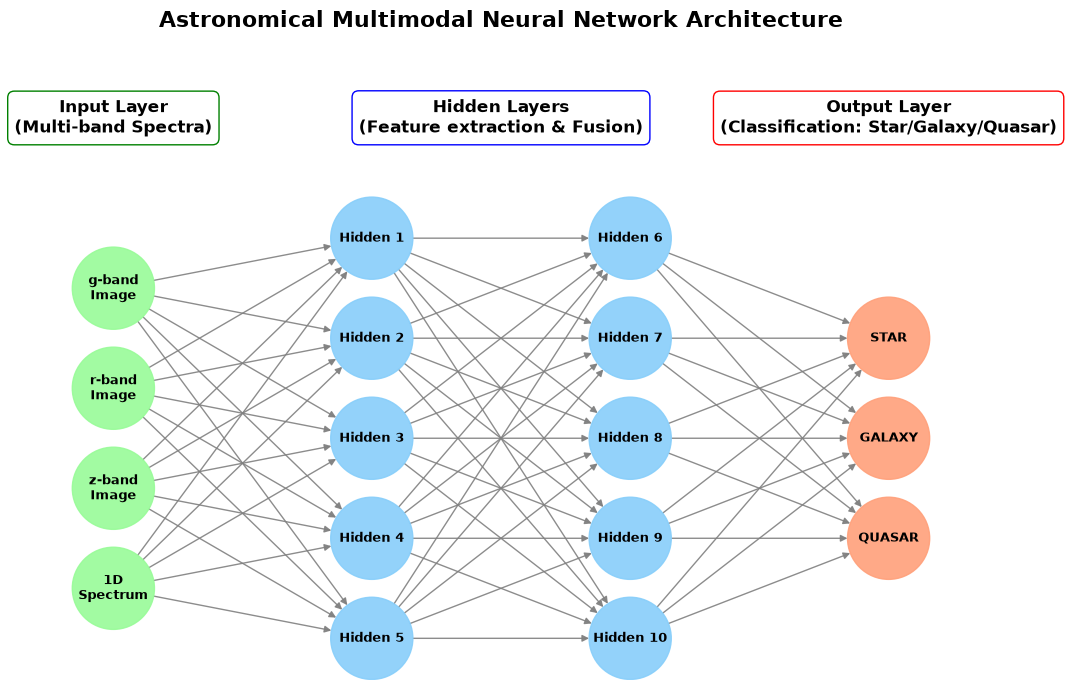

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_labeled_neural_net(ax):
    """Draws a fully labeled neural network diagram tailored to the SDSS project."""
    G = nx.DiGraph()

    # Define exact labels for each layer to show what the network is actually doing
    layers = [
        ["g-band\nImage", "r-band\nImage", "z-band\nImage", "1D\nSpectrum"], # Input Layer
        ["Hidden 1", "Hidden 2", "Hidden 3", "Hidden 4", "Hidden 5"],        # Hidden Layer 1
        ["Hidden 6", "Hidden 7", "Hidden 8", "Hidden 9", "Hidden 10"],       # Hidden Layer 2
        ["STAR", "GALAXY", "QUASAR"]                                         # Output Layer
    ]

    pos = {}
    labels = {}
    node_colors = []

    v_spacing = 1.2
    h_spacing = 2.5

    # Generate nodes and assign specific labels
    for i, layer in enumerate(layers):
        layer_size = len(layer)
        layer_top = v_spacing * (layer_size - 1) / 2.

        for j, label in enumerate(layer):
            node_id = f"L{i}_N{j}"
            G.add_node(node_id, layer=i)
            # Calculate coordinates for the node
            pos[node_id] = (i * h_spacing, layer_top - j * v_spacing)
            labels[node_id] = label

            # Color-code based on layer type
            if i == 0:
                node_colors.append('#98FB98') # Pale Green for Inputs
            elif i == len(layers) - 1:
                node_colors.append('#FFA07A') # Light Salmon for Outputs
            else:
                node_colors.append('#87CEFA') # Light Sky Blue for Hidden

            # Connect every node in this layer to every node in the previous layer
            if i > 0:
                for k in range(len(layers[i-1])):
                    prev_node = f"L{i-1}_N{k}"
                    G.add_edge(prev_node, node_id)

    # Draw the structural graph with larger nodes to accommodate text
    nx.draw(G, pos, ax=ax, with_labels=False, node_size=3500,
            node_color=node_colors, edge_color='gray',
            arrows=True, arrowsize=10, width=1.0, alpha=0.9)

    # Overlay the specific text labels inside the nodes
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

    # Add overarching layer titles (mimicking the boxed groupings in standard diagrams)
    title_y_pos = max([p[1] for p in pos.values()]) + 1.2
    ax.text(0 * h_spacing, title_y_pos, "Input Layer\n(Multi-band Spectra)",
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='green', boxstyle='round,pad=0.4'))

    ax.text(1.5 * h_spacing, title_y_pos, "Hidden Layers\n(Feature extraction & Fusion)",
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.4'))

    ax.text(3 * h_spacing, title_y_pos, "Output Layer\n(Classification: Star/Galaxy/Quasar)",
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.4'))

    # Expand margins so the title boxes are not cut off
    ax.set_xlim(-1, 3 * h_spacing + 1)
    ax.set_ylim(-max([p[1] for p in pos.values()]) - 0.5, title_y_pos + 1)

# Render the plot
fig, ax = plt.subplots(figsize=(11, 7))
draw_labeled_neural_net(ax)
plt.title("Astronomical Multimodal Neural Network Architecture", fontsize=16, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Mathematical Architecture Visualization
To demonstrate rigorous analytical depth, this diagram replaces standard "black box" hidden layer nodes with their actual tensor operations. It visualizes the 2D convolutions applied to the spatial images, the 1D dilated convolutions applied to the spectra, and the Cross-Attention matrix multiplications that fuse them together.

## Task-11: Mathematical Operations of the Dual-Stream Astro-CNN

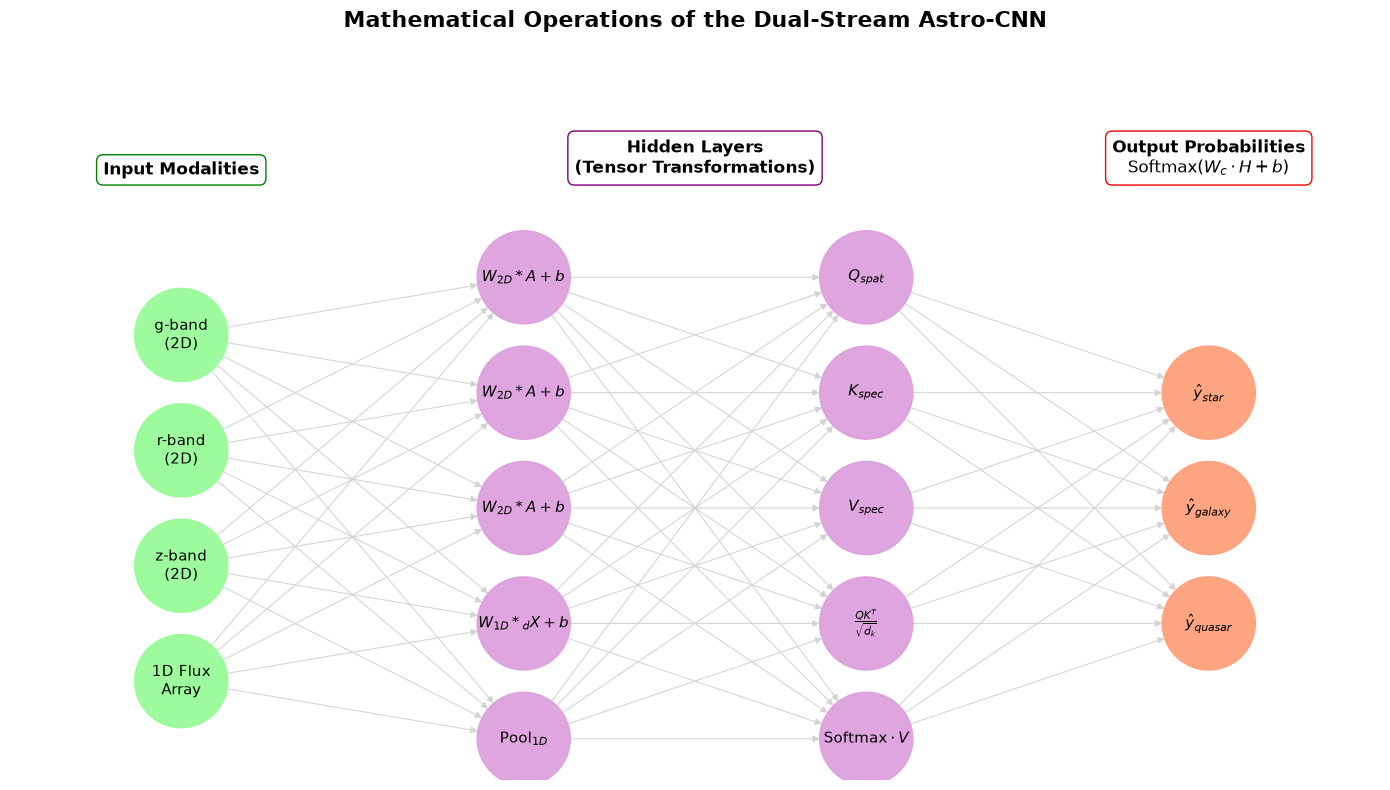

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_mathematical_neural_net(ax):
    G = nx.DiGraph()

    # Define mathematical representations for each specific node
    layers = [
        # Input Layer
        ["g-band\n(2D)", "r-band\n(2D)", "z-band\n(2D)", "1D Flux\nArray"],

        # Hidden Layer 1: Independent Feature Extraction
        [r"$W_{2D} * A + b$", r"$W_{2D} * A + b$", r"$W_{2D} * A + b$", r"$W_{1D} *_{d} X + b$", r"$\text{Pool}_{1D}$"],

        # Hidden Layer 2: Cross-Attention & Fusion
        [r"$Q_{spat}$", r"$K_{spec}$", r"$V_{spec}$", r"$\frac{Q K^T}{\sqrt{d_k}}$", r"$\text{Softmax} \cdot V$"],

        # Output Layer: Probabilities
        [r"$\hat{y}_{star}$", r"$\hat{y}_{galaxy}$", r"$\hat{y}_{quasar}$"]
    ]

    pos = {}
    labels = {}
    node_colors = []

    v_spacing = 1.4
    h_spacing = 3.0

    for i, layer in enumerate(layers):
        layer_size = len(layer)
        layer_top = v_spacing * (layer_size - 1) / 2.

        for j, label in enumerate(layer):
            node_id = f"L{i}_N{j}"
            G.add_node(node_id, layer=i)
            pos[node_id] = (i * h_spacing, layer_top - j * v_spacing)
            labels[node_id] = label

            if i == 0:
                node_colors.append('#98FB98') # Inputs
            elif i == len(layers) - 1:
                node_colors.append('#FFA07A') # Outputs
            else:
                node_colors.append('#DDA0DD') # Mathematical Hidden Nodes (Plum)

            # Connect layers (simplified mapping for visual clarity)
            if i > 0:
                for k in range(len(layers[i-1])):
                    prev_node = f"L{i-1}_N{k}"
                    G.add_edge(prev_node, node_id)

    # Draw graph with larger nodes to fit LaTeX equations
    nx.draw(G, pos, ax=ax, with_labels=False, node_size=4500,
            node_color=node_colors, edge_color='lightgray',
            arrows=True, arrowsize=10, width=0.8, alpha=0.95)

    # Overlay the mathematical LaTeX labels
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_color='black')

    # Add Overarching Layer Titles
    title_y_pos = max([p[1] for p in pos.values()]) + 1.2

    ax.text(0 * h_spacing, title_y_pos, "Input Modalities",
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='green', boxstyle='round,pad=0.4'))

    ax.text(1.5 * h_spacing, title_y_pos, "Hidden Layers\n(Tensor Transformations)",
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='purple', boxstyle='round,pad=0.4'))

    ax.text(3 * h_spacing, title_y_pos, "Output Probabilities\n" + r"$\text{Softmax}(W_c \cdot H + b)$",
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.4'))

    ax.set_xlim(-1.5, 3 * h_spacing + 1.5)
    ax.set_ylim(-max([p[1] for p in pos.values()]) - 0.5, title_y_pos + 1.5)

fig, ax = plt.subplots(figsize=(14, 8))
draw_mathematical_neural_net(ax)
plt.title("Mathematical Operations of the Dual-Stream Astro-CNN", fontsize=16, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()